# Latent Diffusion on MNIST

1. To tackle *conditional* generation, we will employ *classifier-free guidance* (CFG).
2. To parameterize our learned vector field for high-dimensional image-valued data, a simple MLP will not suffice. Instead, we adopt the *diffusion transformer* architecture (see part 2).

In [ ]:
import os
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple
import math
import uuid
import random

import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.func import vmap, jacrev
from tqdm import tqdm
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from einops import rearrange
from einops.layers.torch import Rearrange

### Part 0: Basic Components

In [2]:
class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
        """
        pass

A dataset like MNIST contains both images (in this case handwritten digits), as well as class labels (a value from 0-9 indicating). We therefore generalize `Sampleable` to `LabeledSampleable` to accommodate these labels as well. Whereas the old, `Sampleable.sample` method returned only `samples: torch.Tensor`, `LabeledSampleable.sample` will return both `samples: torch.Tensor` *and* `labels: Optional[torch.Tensor]`. In this way, we are formally realizing every such `Sampleable` instance as sampling from a *joint distribution* over data and labels.

In [3]:
class LabeledSampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
            - labels: b
        """
        pass

For certain distributions, such as a Gaussian, it doesn't really make sense to think about labels. For this reason, we implement our Gaussian class as a simple Sampleable.

In [4]:
class IsotropicGaussian(nn.Module, Sampleable):
    """
    Sampleable wrapper around torch.randn
    """
    def __init__(self, shape: List[int], std: float = 1.0):
        """
        shape: shape of sampled data
        """
        super().__init__()
        self.shape = shape
        self.std = std
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...

    def sample(self, num_samples) -> torch.Tensor:
        return self.std * torch.randn(num_samples, *self.shape).to(self.dummy.device)

Our latent diffusion model is an instance of a conditional probability path. In general, diffusion works by finding the marginal path of a learned vector field from transforming a random (or arbitrary) distribution to the target distribution, which is described by the image dataset.

In [5]:
class ConditionalProbabilityPath(nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """
    def __init__(self, p_simple: Sampleable, p_data: LabeledSampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z) p(z)
        Args:
            - t: b
        Returns:
            - x: samples from p_t(x), b ... (i.e.,. `b d`, `b c h w`, etc.)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z, _ = self.sample_conditioning_variable(num_samples) # (b ...)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t) # (b ...)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        pass

    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable b ...
            - t: time b
        Returns:
            - x: samples from p_t(x|z), b ...
        """
        pass

    @abstractmethod
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field b c h w
        """
        pass

    @abstractmethod
    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - score: b ...
        """
        pass

`LinearAlpha` and `LinearBeta`, for VAE training.

Also, to save on compute, we use a `GaussianConditionalProbabilityPath` instead of a sophisticated learned scheduler. This does sacrifice performance, but it also makes it feasible to train (relatively) quickly.

In [6]:
class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,)), torch.zeros(1,)
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(torch.ones(1,)), torch.ones(1,)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt a_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)

class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1)), torch.ones(1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1)), torch.zeros(1)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: b
        Returns:
            - d/dt beta_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)

class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """

    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        return t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t b
        """
        return torch.ones_like(t)

class LinearBeta(Beta):
    """
    Implements beta_t = 1-t
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        return 1-t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t: b
        """
        return - torch.ones_like(t)

class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple_shape: List[int], alpha: Alpha, beta: Beta):
        p_simple = IsotropicGaussian(shape = p_simple_shape, std = 1.0)
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
        self.rearrange_scalar = Rearrange(f'b -> b{" 1" * len(p_simple_shape)}')

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        return self.p_data.sample(num_samples)

    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: b ...
            - t: b
        Returns:
            - x: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t)) # (b 1 1 1)
        beta_t = self.rearrange_scalar(self.beta(t)) # (b 1 1 1)
        return alpha_t * z + beta_t * torch.randn_like(z)

    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b c h w
            - z: b c h w
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """
        alpha_t = self.rearrange_scalar(self.alpha(t)) # b
        beta_t = self.rearrange_scalar(self.beta(t)) # b
        dt_alpha_t = self.rearrange_scalar(self.alpha.dt(t)) # b
        dt_beta_t = self.rearrange_scalar(self.beta.dt(t)) # b

        return (dt_alpha_t - dt_beta_t / beta_t * alpha_t) * z + dt_beta_t / beta_t * x

    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_score: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t))
        beta_t = self.rearrange_scalar(self.beta(t))
        return (z * alpha_t - x) / beta_t ** 2

Based on Stable Diffusion 3 and Flux 2, we use rectified flow as our sampling technique during inference of the LDM (latent diffusion model).

In [7]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: b ...
            - t: b
        Returns:
            - drift_coefficient: b ...
        """
        pass

In [8]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: b ...
            - t: b
            - dt: b
        Returns:
            - nxt: b ...
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: b ...
            - ts: b
        Returns:
            - x_final: b ...
        """
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x: b ...
            - ts: b nt
        Returns:
            - x_traj: b nt ...
        """
        x_traj = [x.clone()]
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:,t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            x_traj.append(x.clone())
        return torch.stack(x_traj, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        h = h.view([-1] + [1] * (len(xt.shape) - 1))
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

Finally, basic `Trainer` definition.

In [9]:
MiB = 1024 ** 2

def model_size_b(model: nn.Module) -> int:
    """
    Returns model size in bytes. Based on https://discuss.pytorch.org/t/finding-model-size/130275/2
    Args:
    - model: self-explanatory
    Returns:
    - size: model size in bytes
    """
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size


class Trainer(ABC):
    def __init__(
        self,
        **kwargs
      ):
        super().__init__()
        self.model = None
        self.opt = None
        self.output_dir = None

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def checkpoint(self, step: int):
      pass

    def get_optimizer(self, lr: float):
        return torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

    def random_name(self) -> str:
        adjectives = ["autumn", "hidden", "bitter", "misty", "silent", "empty", "dry", "dark", "summer", "icy", "delicate", "quiet", "white", "cool", "spring", "winter", "patient"]
        foods = ["apple", "banana", "pear", "plum", "orange", "persimmon", "tangerine", "durian", "jackfruit", "jicama", "cantaloupe", "watermelon", "peach"]
        return f"{random.choice(adjectives)}-{random.choice(foods)}-{str(uuid.uuid4())[:8]}"

    def train(
        self,
        model: nn.Module,
        num_steps: int,
        lr: float = 1e-3,
        warmup_steps: int = 500,
        ckpt_every: Optional[int] = 500,
        run_name: Optional[str] = None,
        **kwargs
    ) -> Tuple[List[float], List[int]]:
        """
        Linear warmup from 0 -> lr over `warmup_steps`, then constant lr.
        """
        # Initialize run name and output directory
        run_name = run_name or self.random_name()
        self.output_dir = os.path.join("runs", run_name)
        os.makedirs(self.output_dir, exist_ok=False)
        print("Initialized output directory at: " + self.output_dir)

        # Grab size
        self.model = model
        size_b = model_size_b(self.model)
        print(f"Training model with size: {size_b / MiB:.3f} MiB")

        # Initialize optimizer and LR
        self.opt = self.get_optimizer(lr)
        self.model.train()

        for pg in self.opt.param_groups:
            pg["lr"] = 0.0

        # Main training loop
        losses: List[float] = []
        steps: List[int] = []

        pbar = tqdm(range(num_steps))
        for step in pbar:
            # Update LR
            if warmup_steps > 0 and step < warmup_steps:
                cur_lr = lr * float(step + 1) / float(warmup_steps)
            else:
                cur_lr = lr
            for pg in self.opt.param_groups:
                pg["lr"] = cur_lr

            # Forward + backward
            self.opt.zero_grad(set_to_none=True)
            loss = self.get_train_loss(**kwargs)
            loss.backward()

            # Take gradient step
            self.opt.step()

            losses.append(float(loss.detach().item()))
            steps.append(step)

            pbar.set_description(f"Step {step}, lr={cur_lr:.2e}, loss={loss.item():.4f}")

            # Callback if specified
            if ckpt_every is not None and step % ckpt_every == 0 and step > 0:
              self.model.eval()
              self.checkpoint(step)
              self.model.train()

        self.model.eval()
        return losses, list(range(num_steps))

# Part 1: MNIST Sampling

In [10]:
class MNISTSampler(nn.Module, LabeledSampleable):
    """
    Sampleable wrapper for the MNIST dataset
    """
    def __init__(self):
        super().__init__()
        self.dataset = datasets.MNIST(
            root='./data',
            train=True,
            download=True,
            transform=transforms.Compose([
                transforms.Resize((32, 32)),
                transforms.ToTensor(),
                transforms.Normalize((0.1305,), (0.2891,)),
            ])
        )
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, c, h, w)
            - labels: shape (batch_size, label_dim)
        """
        if num_samples > len(self.dataset):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.dataset)}")

        indices = torch.randperm(len(self.dataset))[:num_samples]
        samples, labels = zip(*[self.dataset[i] for i in indices])
        samples = torch.stack(samples).to(self.dummy)
        labels = torch.tensor(labels, dtype=torch.int64).to(self.dummy.device)
        return samples, labels

In [11]:
class ConditionalVectorField(nn.Module, ABC):
    """
    Conditional vector field u_t^theta(x|y)
    """

    @abstractmethod
    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        Returns:
        - u_t^theta(x|y): b ...
        """
        pass

class CFGVectorFieldODE(ODE):
    def __init__(self, net: ConditionalVectorField, null_label: int, guidance_scale: float = 1.0):
        self.net = net
        self.guidance_scale = guidance_scale
        self.null_label = null_label

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        """
        guided_vector_field = self.net(x, t, y)
        unguided_y = torch.ones_like(y) * self.null_label
        unguided_vector_field = self.net(x, t, unguided_y)
        return (1 - self.guidance_scale) * unguided_vector_field + self.guidance_scale * guided_vector_field


In [12]:
class MLP(nn.Module):
  def __init__(self, dims: List[int], activation: Type[torch.nn.Module] = torch.nn.SiLU, final_init: bool = False):
    super().__init__()
    mlp = []
    for idx in range(len(dims) - 1):
        mlp.append(torch.nn.Linear(dims[idx], dims[idx + 1]))
        if idx < len(dims) - 2:
            mlp.append(activation())
    self.net = torch.nn.Sequential(*mlp)

    if final_init:
      nn.init.zeros_(self.net[-1].weight)
      nn.init.zeros_(self.net[-1].bias)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b n d
    """
    return self.net(x)

# Part 2: Building a Diffusion Transformer

### Classifier-Free Guidance

Used to increase prompt adherence (in our case, label adherence, since we're not including a text incoder to do full text-to-image).

Maps a scalar time value $t \in [0,1]$ to
$$
    t^{\text{emb}} = \begin{bmatrix}
    \cos(2\pi w_1 t) & \cdots & \cos(2\pi w_d t) & \sin(2\pi w_1 t) & \cdots & \sin(2\pi w_d t)
    \end{bmatrix}^T,
$$
where the weights $w_i \sim \mathcal{N}(0, 1)$ are drawn from a unit normal.

In [13]:
class FourierEncoder(nn.Module):
    """
    Based on https://github.com/lucidrains/denoising-diffusion-pytorch/blob/main/denoising_diffusion_pytorch/karras_unet.py#L183
    """
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - t: b
        Returns:
        - embeddings: b d
        """
        # Step 1: compute frequencies f_i = 2 * pi * w_i * t
        t = t.view(-1, 1) # b 1
        freqs = t * self.weights * 2 * math.pi # b hd

        # Step 2: compute sin(f_i) and cos(f_i)
        sin_embed = torch.sin(freqs) # b hd
        cos_embed = torch.cos(freqs) # b hd

        # Step 3: Concatenate and return
        return torch.cat([sin_embed, cos_embed], dim=-1) * math.sqrt(2) # b d

### Patchifier

The patchifier takes in an image-valued tensor of shape `b c 32 32`, and *patchifies* it to shape `b (h / p * w / p) d`, where `d` denotes the diffusion transformer hidden dimension (`dim` in the implementation below), `p` denotes the patch size, and `h` and `w` denote the image height and width, respectively. It does this in two steps:
1. Applies a convolutional layer mapping the an input of shape `b c 32 32` to `b d h/p h/w`.
2. Rearranges from `b d h/p h/w` to `b (h/p h/w) d` (i.e., `n = h/p * h/w` tokens with dimension `d`).

In [14]:
class Patchifier(nn.Module):
  def __init__(self, img_size: int, patch_size: int, c_in: int, dim: int):
    super().__init__()
    assert img_size % patch_size == 0, "Image size must be divisible by patch size"

    self.net = nn.Sequential(
        # Initial convolution
        nn.Conv2d(c_in, dim, kernel_size=patch_size, stride=patch_size),

        # Patchify
        Rearrange("b d h w -> b (h w) d"),
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: (bs, 1, img_size, img_size)
    Returns:
    - x: (bs, 1, img_size, img_size)
    """
    return self.net(x)

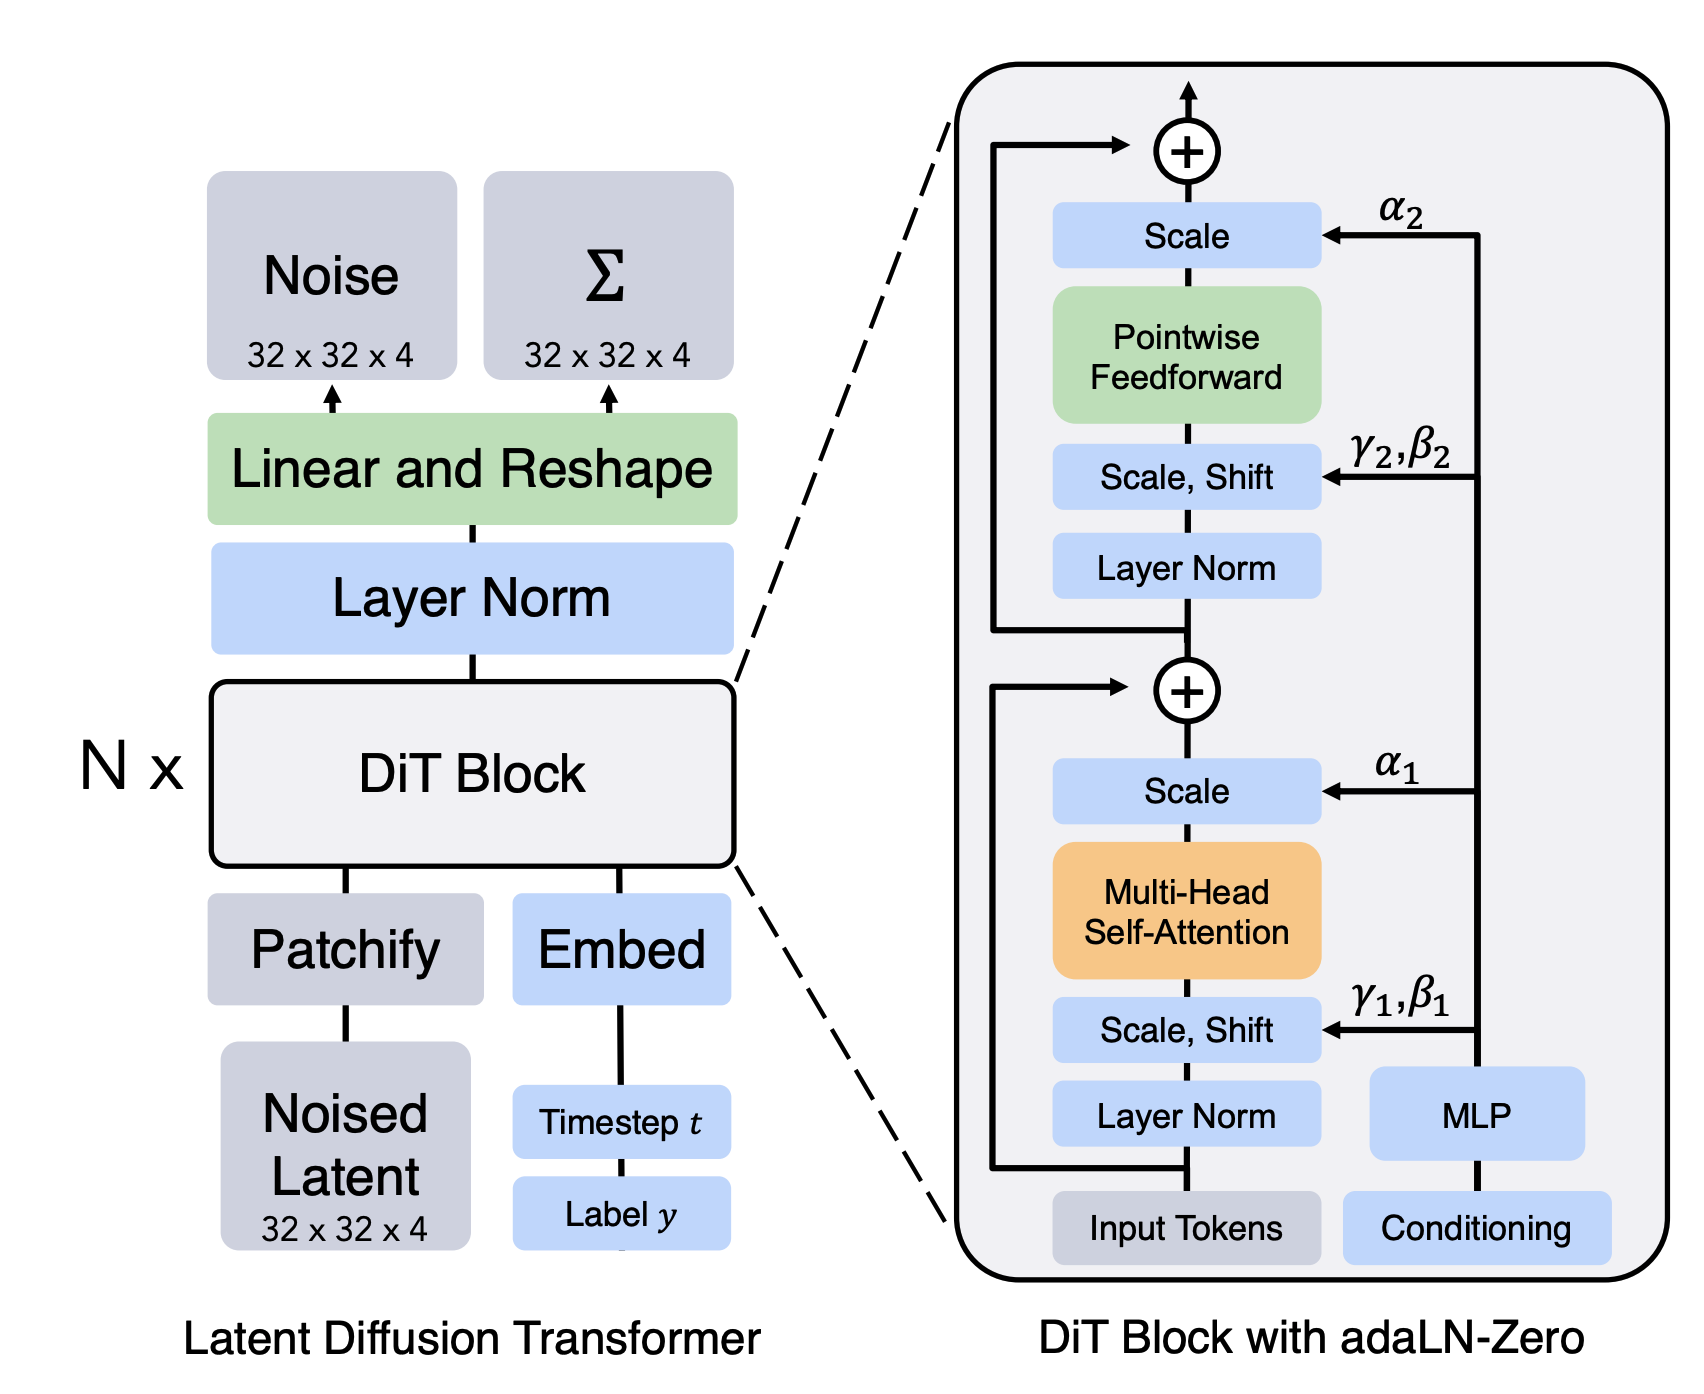

### Diffusion Transformer
Our data is now in the shape `b n d`, where `n` denotes the number of image tokens per image. We'll now pass it through a transformer

**Pieces:**
1. `DiffusionTransformerLayer` is based on the diagram above. AdaLN-Zero refers to zero-initializing the conditioning MLP weights (the last layer will suffice), which often helps to stablize training.
2. `DiffusionTransformer`learns fixed per-position encodings using e.g., `nn.Parameter(torch.randn(n_tokens, dim))`. A forward pass simply involves adding the positional encodings to your input and passing through the diffusion transformer layers.

In [15]:
class MHA(nn.Module):
  """
  Multi-headed self-attention
  """
  def __init__(self, dim: int, heads: int):
    super().__init__()
    assert dim % heads == 0

    self.mha = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b n d

    nn.MultiheadAttention expects (batch, seq_len, dim) if batch first is true
    """
    out, _ = self.mha(x, x, x)
    return out

def modulate(x: torch.Tensor, scale: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    - scale: b n d
    - bias: b n d
    Returns:
    - x: b n d
    """
    return x * (1 + scale) + bias

class DiffusionTransformerLayer(nn.Module):
  def __init__(
      self,
      dim: int,
      heads: int,
  ):
    """
    Args:
    - n_tokens: sequence length (for sake of positional embeddings)
    - dim: dimension of hidden layers
    - heads: number of attention heads
    """
    super().__init__()

    # Init normalization

    # AdaLN provides affine parameters
    self.norm1 = nn.RMSNorm(dim, elementwise_affine=False)
    self.norm2 = nn.RMSNorm(dim, elementwise_affine=False)

    self.ada_ln = nn.Sequential(
        nn.RMSNorm(dim, elementwise_affine=False),
        nn.Linear(dim, dim * 6)
    )

    # Initialize conditioning to zero - stabilizes residual connection
    nn.init.zeros_(self.ada_ln[1].weight)
    nn.init.zeros_(self.ada_ln[1].bias)

    # Attention
    self.attn = MHA(dim, heads)

    # Feedforward
    self.ff = MLP([dim, 4 * dim, dim])

  def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    - c: b d
    Returns:
    - x: b n d
    """
    # Compute conditioning gating, scaling, and bias

    # Faster than looping through each part of the adaptive layer norm
    c = rearrange(self.ada_ln(c), 'b d -> b 1 d') # b 1 d
    attn_scale, attn_bias, attn_gate, ff_scale, ff_bias, ff_gate = c.chunk(6, dim=-1)

    # Attention + FF
    x = x + attn_gate * self.attn(
      modulate(self.norm1(x), attn_scale, attn_bias)
    )
    x = x + ff_gate * self.ff(
      modulate(self.norm2(x), ff_scale, ff_bias)
    )
    return x

class DiffusionTransformer(nn.Module):
  def __init__(
      self,
      depth: int,
      n_tokens: int,
      dim: int,
      **layer_kwargs,
  ):
    """
    Args:
    - n_tokens: sequence length (for sake of positional embeddings)
    - dim: dimension of hidden layers
    - heads: number of attention heads
    - depth: number of layers
    """
    super().__init__()
    self.layers = nn.ModuleList([])
    for _ in range(depth):
      self.layers.append(DiffusionTransformerLayer(dim=dim, **layer_kwargs))

    # Positional encodings
    self.pos_encodings = nn.Parameter(torch.randn(n_tokens, dim))

  def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Add positional encoding to input and pass through diffusion layers

    Args:
    - x: b n d
    - c: b d
    Returns:
    - x: b n d
    """
    x = x + self.pos_encodings.unsqueeze(0)
    for layer in self.layers:
      x = layer(x, c)
    return x

### Depatchifier
After the diffusion transformer, we need to convert from `b n d` back to `b 1 h w`.

In [16]:
class Depatchifier(nn.Module):
  def __init__(self, img_size: int, patch_size: int, dim: int, final_dim: int, c_out: int):
      super().__init__()
      self.patch_size = patch_size
      assert img_size % patch_size == 0, "Image size must be divisible by patch size"
      h = w = img_size // patch_size


      self.net = nn.Sequential(
          # Norm + MLP
          nn.RMSNorm(dim, elementwise_affine=False),
          MLP([dim, 4*dim, final_dim * patch_size ** 2]),

          # Depatchify
          Rearrange("b (h w) (f ph pw) -> b f (h ph) (w pw)", h=h, w=w, f=final_dim, ph=patch_size, pw=patch_size),

          # Final convolution
          nn.Conv2d(final_dim, c_out, kernel_size=3, padding=1)
      )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b 1 32 32
    """
    return self.net(x)

### DiffusionTransformerFlowModel

DiT-based guided flow model $u_t^\theta(x|y)$ based on the DiT overview diagram.

In [17]:
class DiffusionTransformerFlowModel(ConditionalVectorField):
  def __init__(
      self,
      img_size: int = 32,
      patch_size: int = 8,
      num_layers: int = 12,
      c: int = 1,
      dim: int = 256,
      heads: int = 4,
      final_dim: int = 10,
      n_classes: int = 11,
    ):
      super().__init__()
      # 0. Construct time_embedder and y_embedder
      self.time_embedder = FourierEncoder(dim)
      self.y_embedder = nn.Embedding(num_embeddings = n_classes, embedding_dim = dim)

      # 1. Construct patchifier
      self.patchifier = Patchifier(
          img_size=img_size,
          patch_size=patch_size,
          c_in=c,
          dim=dim
        )

      # 2. Construct DiT
      n_tokens = (img_size // patch_size) ** 2
      self.dit = DiffusionTransformer(
          depth=num_layers,
          n_tokens=n_tokens,
          dim=dim,
          heads=heads,
      )

      # 3. Construct de-patchifier
      self.depatchifier = Depatchifier(
          img_size=img_size,
          patch_size=patch_size,
          dim=dim,
          final_dim=final_dim,
          c_out=c
        )

  def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b 1 32 32
    - t: b 1 1 1
    - c: b 1 1 1
    Returns:
    - u_t^theta(x|y): b 1 32 32
    """
    # 1. Embed time and y
    t_embed = self.time_embedder(t) # b d
    y_embed = self.y_embedder(y) # b d

    # 2. Patchify
    x = self.patchifier(x) # b n d

    # 3. Pass through DiT
    x = self.dit(x, t_embed + y_embed) # b d

    # 4. Depatchify
    x = self.depatchifier(x) # b 1 32 32

    return x

# Part 3: Training a Variational Autoencoder

In this section, we'll train a variational autoencoder (VAE) for MNIST. In the next section, we'll then train a diffusion transformer inside of the learned latent space.

**Pieces:**
1. an *encoder* $q_\phi(z|x)$, mapping the input `x` with shape `b 1 32 32`, to outputs `z_mean` with shape `b c h w` and learned scalar `z_logvar`. For training stability reasons, and in following the precedent of [2], we choose to indirectly parameterize the log-variance $\log \sigma_\phi(x)$.
2. a *decoder* $p_\theta(x|z)$ which similarly maps the latent `z` to outputs `x_mean` with shape `b 1 32 32` and learned scalar `x_logvar`.

### Residual Block

In [18]:
class ResidualBlock(nn.Module):
  """ Two applications of LN + convolution + non-linearity + residual connection """
  def __init__(self, channels: int, act: nn.Module = nn.SiLU):
    super().__init__()

    # Init norm, convolutions, and activations
    self.norm = nn.GroupNorm(num_groups=1, num_channels=channels)
    self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(channels, channels, kernel_size=1, padding=0)
    self.activation = act()

    # Initialize the second convolution to zero to stabilize training early on
    nn.init.zeros_(self.conv2.weight)
    nn.init.zeros_(self.conv2.bias)

  def forward(self, x: torch.Tensor):

    # Res init
    x_skip = x

    # Norm
    x = self.norm(x)

    # First convolution
    x = self.conv1(x)

    # Activation
    x = self.activation(x)

    # Second convolution
    x = self.conv2(x)

    # Return residual connection
    return x_skip + x

### Attention Block

In [19]:
class AttentionBlock(nn.Module):
  def __init__(self, channels: int):
    super().__init__()

    # Reshape from image shape to list of tokens shape
    self.reshape1 = Rearrange('b c h w -> b (h w) c')

    # Norm + attention
    self.norm1 = nn.LayerNorm(channels)
    self.mha = MHA(channels, 1)

    # Norm + feed forward
    self.norm2 = nn.LayerNorm(channels)
    self.feedforward = MLP([channels, 2 * channels, channels], final_init=True)

  def forward(self, x: torch.Tensor):
    b, c, h, w = x.shape
    x = self.reshape1(x)

    x_skip = x

    # Attention + residual connection
    x = self.norm1(x)
    x = self.mha(x)
    x = x + x_skip

     # Feedforward + residual connection
    x_skip = x
    x = self.norm2(x)
    x = self.feedforward(x)
    x = x + x_skip

    return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)

### Encoder

In [20]:
class EncoderBlock(nn.Module):
  def __init__(self, in_channels: int, downsample_channels: Optional[int] = None):
    super().__init__()

    self.net = nn.Sequential(
      ResidualBlock(in_channels),
      ResidualBlock(in_channels),
      AttentionBlock(in_channels),
    )

    if downsample_channels is not None:
      self.downsample = nn.Conv2d(in_channels = in_channels, out_channels = downsample_channels, padding=1, stride=2, kernel_size=3)
    else:
      self.downsample = None

  def forward(self, x: torch.Tensor):

    x = self.net(x)
    if self.downsample is not None:
      x = self.downsample(x)
    return x


class Encoder(nn.Module):
  def __init__(self, in_channels: int, hidden_channels: list[int]):
    super().__init__()

    # Initial conv2d
    self.init_conv = nn.Conv2d(in_channels = in_channels, out_channels = hidden_channels[0], kernel_size=3, padding=1, stride=1)

    # Initialize channels
    ch_in = hidden_channels
    ch_out = hidden_channels[1:] + [None]
    blocks = []
    for in_c, out_c in zip(ch_in, ch_out):
      blocks.append(EncoderBlock(in_c, out_c))
    self.blocks = nn.ModuleList(blocks)

    # Predict z_mean
    z_dim = hidden_channels[-1]
    self.z_mean = nn.Sequential(
      nn.GroupNorm(1, z_dim),
      nn.Conv2d(in_channels = z_dim, out_channels = z_dim, kernel_size=1, stride=1, padding=0),
    )

    # Scalar log-variance
    self.logvar = nn.Parameter(torch.zeros(()))

  def forward(self, x: torch.Tensor):
    # Initial convolution
    x = self.init_conv(x)

    # Pass through blocks
    for block in self.blocks:
      x = block(x)

    # Final normalization + convolution to get z_mean
    return self.z_mean(x), self.logvar


### Decoder

In [21]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels: int, upsample_channels: Optional[int] = None):
    super().__init__()
    self.net = nn.Sequential(
      ResidualBlock(in_channels),
      ResidualBlock(in_channels),
      AttentionBlock(in_channels),
    )
    if upsample_channels is not None:
      self.upsample = nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_channels=in_channels, out_channels=upsample_channels, kernel_size=3, padding=1, stride=1),
      )
    else:
      self.upsample = None

  def forward(self, x: torch.Tensor):
    x = self.net(x)
    if self.upsample is not None:
      x = self.upsample(x)
    return x

class Decoder(nn.Module):
  def __init__(self, out_channels: int, hidden_channels: list[int]):
    super().__init__()

    # Initialize channels
    ch_in = hidden_channels
    ch_out = hidden_channels[1:] + [None]
    blocks = []
    for in_c, out_c in zip(ch_in, ch_out):
      blocks.append(DecoderBlock(in_c, out_c))
    self.blocks = nn.ModuleList(blocks)

    # Predict mean
    x_dim = hidden_channels[-1]
    self.x_mean = nn.Sequential(
      nn.GroupNorm(1, x_dim),
      nn.Conv2d(in_channels = x_dim, out_channels = out_channels, kernel_size=1, stride=1, padding=0),
    )

    # Scalar log-variance
    self.logvar = nn.Parameter(torch.zeros(()))

  def forward(self, x: torch.Tensor):
    # Pass through blocks
    for block in self.blocks:
      x = block(x)

    # Final normalization + convolution to get x_mean
    return self.x_mean(x), self.logvar

### Complete VAE

In [22]:
class VAE(nn.Module):
  def __init__(self, data_channels: int, hidden_channels: list[int], beta: float = 0.1):
    super().__init__()
    self.beta = beta

    # Encoder
    self._encoder = Encoder(data_channels, hidden_channels)

    # Decoder
    self._decoder = Decoder(data_channels, list(reversed(hidden_channels)))

  def encode(self, x: torch.Tensor):
    return self._encoder(x)

  def decode(self, z: torch.Tensor):
    return self._decoder(z)

  def forward(self, x: torch.Tensor):
    z_mean, z_logvar = self.encode(x)
    z = z_mean + torch.exp(0.5 * z_logvar) * torch.randn_like(z_mean)
    x_mean, x_logvar = self.decode(z)
    return z_mean, z_logvar, x_mean, x_logvar

  def compute_loss(self, z_mean: torch.Tensor, z_logvar: torch.Tensor, x_mean: torch.Tensor, x_logvar: torch.Tensor, x_true: torch.Tensor):
    eps = 1e-6

    # KL loss
    kl_loss = self.beta * (z_mean.pow(2) + torch.exp(z_logvar) - z_logvar - 1).mean()

    # Reconstruction loss
    mse_term = (x_true - x_mean).pow(2) / (torch.exp(x_logvar) + eps)
    recon_loss = (mse_term + x_logvar).mean()

    return kl_loss + recon_loss

Before we train, we create a new `Trainer` subclass with which to train the VAE, and a helper function to visualize interpolation in the learned latent space.

In [23]:
class MNISTVAETrainer(Trainer):
  def __init__(self, mnist_sampleable: LabeledSampleable, batch_size: int = 64, **kwargs):
    super().__init__(**kwargs)
    self.mnist = mnist_sampleable
    self.batch_size = batch_size

  def get_train_loss(self):
    """ See display 85 from the text """
    x, y = self.mnist.sample(self.batch_size)
    z_mean, z_std, x_mean, x_std = self.model(x)
    return self.model.compute_loss(z_mean, z_std, x_mean, x_std, x)

  @torch.no_grad()
  def checkpoint(self, step: int):
    # Save model
    torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:06d}_model.pt'))
    torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:06d}_opt.pt'))

    # Save output visualization, using x_mean as reconstruction
    b = 10
    x, _ = self.mnist.sample(b)
    _, _, x_mean, _ = self.model(x)
    x_all = torch.cat([x, x_mean], dim=0)
    grid = make_grid(x_all, nrow=b, normalize=True, value_range=(0,1))
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    plt.axis("off")
    plt.title("VAE Reconstruction")
    plt.savefig(os.path.join(self.output_dir, f'step_{step:06d}_output.png'))
    plt.close()

@torch.no_grad()
def visualize_latent_interpolation(x1: torch.Tensor, x2: torch.Tensor, vae: VAE, n_steps: int, save_path: Optional[str] = None):
   z1_mean, z1_logvar = vae.encode(x1)
   z1 = z1_mean + torch.exp(0.5 * z1_logvar) * torch.randn_like(z1_mean) # 1 c h w

   z2_mean, z2_logvar = vae.encode(x2)
   z2 = z2_mean + torch.exp(0.5 * z2_logvar) * torch.randn_like(z2_mean) # 1 c h w

   lambdas = torch.linspace(0, 1, n_steps).to(z1.device)
   zs = (1 - lambdas) * z1.unsqueeze(-1) + lambdas * z2.unsqueeze(-1) # 1 c h w n_steps
   zs = rearrange(zs, '1 c h w n -> n c h w')
   samples, _ = vae.decode(zs) # n_steps 1 h w

   grid = make_grid(samples, nrow=n_steps, normalize=True, value_range=(0, 1))
   plt.figure(figsize=(n_steps * 2, 2))
   plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
   plt.axis("off")
   plt.title("Latent Interpolation")
   if save_path is not None:
       plt.savefig(save_path)
       plt.close()
   else:
       plt.show()
   return samples

Finally, let's train the VAE.

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 32.8MB/s]


Initialized output directory at: runs/icy-orange-5c35e57f
Training model with size: 5.488 MiB


Step 4999, lr=1.00e-03, loss=-0.6392: 100%|██████████| 5000/5000 [01:52<00:00, 44.52it/s]


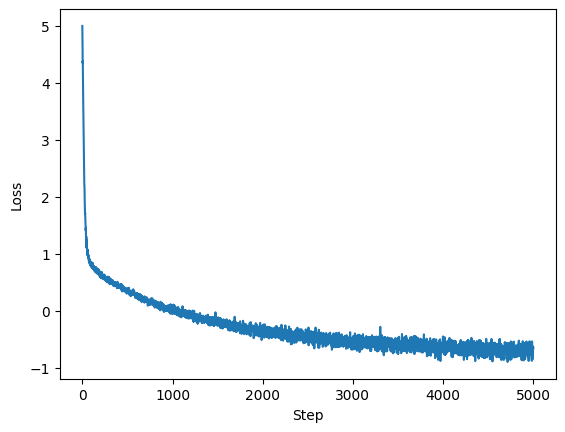

In [24]:
# Create dataset + VAE
device = torch.device('cuda')
mnist = MNISTSampler().to(device)
vae = VAE(
   data_channels = 1,
   hidden_channels = [16, 32, 64, 128],
   beta = 10.0,
).to(device)

# Create Trainer + train
trainer = MNISTVAETrainer(
    mnist_sampleable = mnist,
    batch_size = 64,
)
losses, steps = trainer.train(
   model = vae,
   num_steps = 5000,
   lr = 1e-3,
   warmup_steps = 500,
   ckpt_every = 250,
)
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

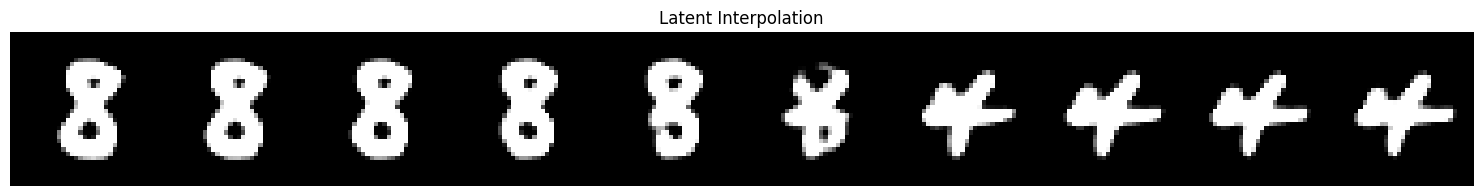

In [25]:
# Perform interpolation in the latent space
vae.eval()
samples, _ = mnist.sample(2)
interpolated_samples = visualize_latent_interpolation(
   x1 = samples[:1],
   x2 = samples[1:2],
   vae = vae,
   n_steps = 10,
) # n_steps 1 h w

# Part 4: Training a Latent Diffusion Model
In this section, we'll train a diffusion transformer inside of the latent space of a trained VAE.

In [26]:
class LatentCFGTrainer(Trainer):
    def __init__(
        self,
        mnist: MNISTSampler,
        vae: VAE,
        path: GaussianConditionalProbabilityPath,
        eta: float,
        null_label: int,
        eps: float = 0.001,
        **kwargs
    ):
        assert eta > 0 and eta < 1
        super().__init__(**kwargs)
        self.mnist = mnist
        self.vae = vae
        self.path = path
        self.eta = eta
        self.eps = eps
        self.path = path
        self.null_label = null_label

    def visualize_samples(self, save_path: str, samples_per_class: int = 10, num_timesteps: int = 100, guidance_scales: List[float] = [1.0, 3.0, 5.0], use_tqdm = False):
      # Graph
      fig, axes = plt.subplots(1, len(guidance_scales), figsize=(10 * len(guidance_scales), 10))

      for idx, w in enumerate(guidance_scales):
          # Setup ode and simulator
          ode = CFGVectorFieldODE(self.model, guidance_scale=w, null_label=10)
          simulator = EulerSimulator(ode)

          # Sample initial conditions
          y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
          num_samples = y.shape[0]
          z0 = self.path.p_simple.sample(num_samples)

          # Simulate
          ts = torch.linspace(0,0.999,num_timesteps).view(1, -1, 1, 1, 1).expand(num_samples, -1, 1, 1, 1).to(device)
          z1 = simulator.simulate(z0, ts, y=y, use_tqdm=use_tqdm)

          # Decode
          x1, _ = self.vae.decode(z1)

          # Plot
          v_min, v_max = x1.min(), x1.max()
          x1 = (x1 - v_min) / (v_max - v_min)
          grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(0,1))
          axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
          axes[idx].axis("off")
          axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)

      # Save
      if save_path is not None:
          plt.savefig(save_path)
          plt.close()
      else:
        plt.show()

    plt.show()

    def checkpoint(self, step: int):
      # Save model
      torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_model.pt'))
      torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_opt.pt'))

      # Save output visualization
      self.visualize_samples(save_path=os.path.join(self.output_dir, f'step_{step:6d}_output.png'))

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample z, y from MNIST + encode
        with torch.no_grad():
          xx, y = self.mnist.sample(batch_size) # b 1 h w, b
          z_mean, z_logvar = self.vae.encode(xx) # b c h w, 1
          zz = z_mean + torch.exp(0.5 * z_logvar) * torch.randn_like(z_mean)

        # Step 2: Set each label to 10 (i.e., null) with probability eta
        yi = torch.rand(y.shape[0]).to(y.device)
        y[yi < self.eta] = self.null_label

        # Step 3: Sample t and x
        t = torch.rand(batch_size).to(zz) * (1 - self.eps) # b
        zx = self.path.sample_conditional_path(zz,t) # b ...

        # Step 4: Regress and output loss
        ut_theta = self.model(zx,t,y) # b ...
        ut_ref = self.path.conditional_vector_field(zx,zz,t) # b ...
        return torch.square(ut_theta - ut_ref).mean()

Initialized output directory at: runs/winter-jicama-1079dc59
Training model with size: 37.357 MiB


Step 9999, lr=4.00e-04, loss=1.9221: 100%|██████████| 10000/10000 [05:49<00:00, 28.62it/s]


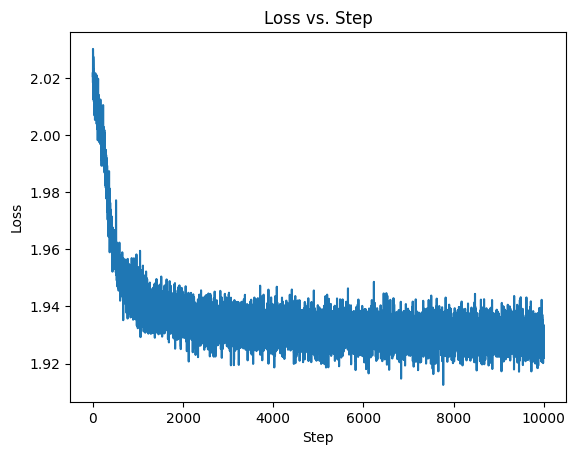

In [27]:
# Finally, let's train!

vae = vae.to(device) # VAE(data_channels = 1, hidden_channels = [16, 32, 64, 128], beta = 1.0)

# Initialize latent probability path
c = 128
img_size = 4

path = GaussianConditionalProbabilityPath(
    p_data = None,
    p_simple_shape = [c, img_size, img_size],
    alpha = LinearAlpha(),
    beta = LinearBeta()
).to(device)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size = img_size,
    patch_size = 1,
    num_layers = 8,
    c = c,
    dim = 256,
    heads = 8,
    final_dim = 10,
    n_classes = 11,
).to(device)

# Dataset
mnist = MNISTSampler().to(device)

# Initialize trainer
trainer = LatentCFGTrainer(
    mnist = mnist,
    vae = vae,
    path = path,
    eta=0.35,
    null_label=10
)

# Train! You should have reasonable results in ~15 A100 minutes
losses, steps = trainer.train(model=dit, num_steps = 10000, lr=0.4e-3, batch_size=256, ckpt_every=500)

plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss vs. Step")
plt.show()

### Inference using the Latent Diffusion Model

100%|██████████| 99/99 [00:00<00:00, 238.60it/s]


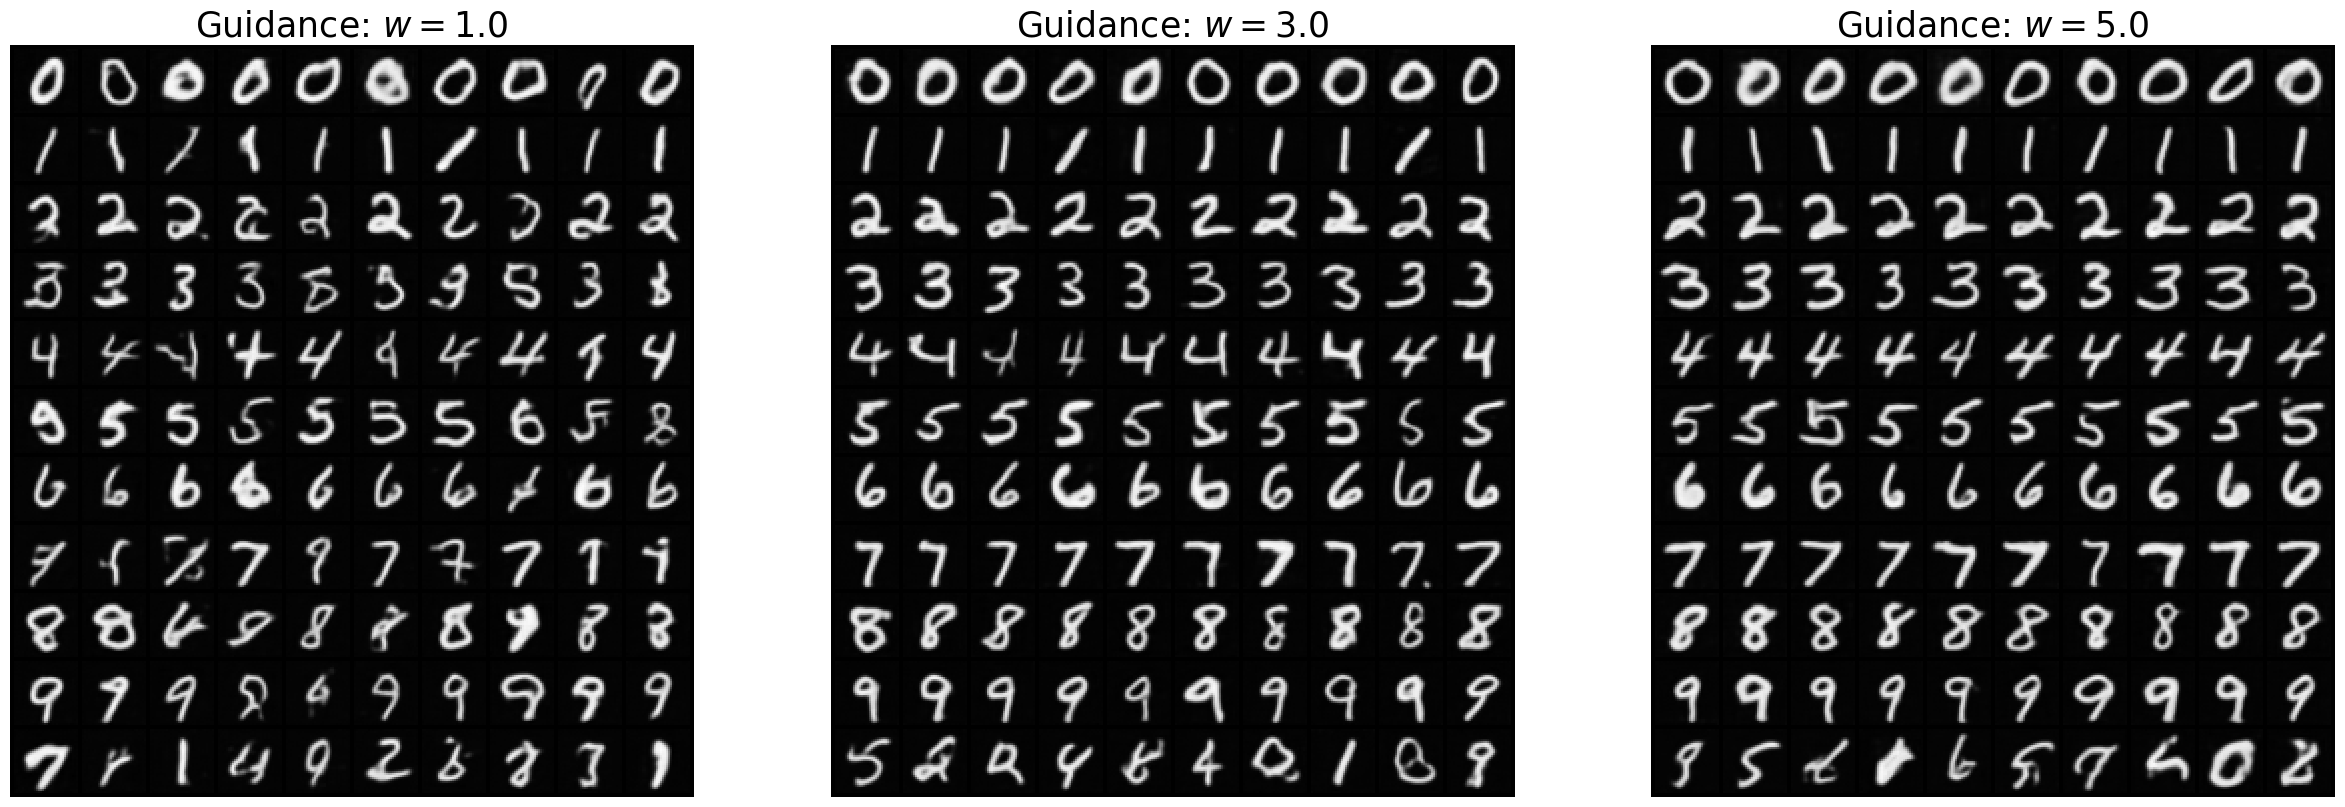

In [30]:
trainer.visualize_samples(save_path=None, use_tqdm=True)

### References:
1. [Scalable Diffusion Models with Transformers](https://arxiv.org/abs/2212.09748)
2. [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752)
3. [Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow](https://arxiv.org/abs/2209.03003)